- DataSet From Kaggele

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pickle

# Load dataset
df = pd.read_csv("mcus.csv")

# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0 or vice versa

# Select features
X = df[['Gender', 'Age', 'Annual Income', 'Spending Score']]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_pca)

# Save models
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(pca, open("pca_model.pkl", "wb"))
pickle.dump(kmeans, open("kmeans_model.pkl", "wb"))

print("✅ All models saved successfully.")


: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


KeyboardInterrupt: 

In [8]:
df = pd.read_csv('mcus.csv')

Doing EDA

In [9]:
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [10]:
df.isnull().sum()

Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

In [11]:
df['Gender'].value_counts()

Gender
Male      7595
Female    7484
Name: count, dtype: int64

In [12]:
df.shape

(15079, 5)

In [13]:
df.describe(include = 'all')


,Customer ID,Age,Gender,Annual Income,Spending Score
count,15079,15079.000000,15079,15079.000000,15079.000000
unique,15079,NaN,2,NaN,NaN
top,d410ea53-6661-42a9-ad3a-f554b05fd2a7,NaN,Male,NaN,NaN
freq,1,NaN,7595,NaN,NaN
mean,NaN,54.191591,NaN,109742.880562,50.591617
std,NaN,21.119207,NaN,52249.425866,28.726977
min,NaN,18.000000,NaN,20022.000000,1.000000
25%,NaN,36.000000,NaN,64141.000000,26.000000
50%,NaN,54.000000,NaN,109190.000000,51.000000
75%,NaN,72.000000,NaN,155008.000000,75.000000


In [ ]:
df.info()

In [ ]:
for col in df.columns:
    unique_values = df[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")


Unique values in column 'Customer ID': ['d410ea53-6661-42a9-ad3a-f554b05fd2a7'
 '1770b26f-493f-46b6-837f-4237fb5a314e'
 'e81aa8eb-1767-4b77-87ce-1620dc732c5e' ...
 '0e87c25a-268c-401a-8ba1-7111dcde6f1a'
 '5f388cbe-3373-4e16-b743-38f508f2249f'
 'b8b8f561-ebca-4401-8afe-544c906554ba']
Unique values in column 'Age': [30 58 62 23 24 42 27 83 37 63 25 32 51 64 19 89 65 26 21 70 39 61 79 73
 90 35 57 76 40 82 84 56 55 45 28 67 69 46 36 48 50 49 80 33 38 54 81 44
 75 60 52 72 68 31 22 71 53 18 88 74 78 59 29 34 87 20 77 41 85 86 47 43
 66]
Unique values in column 'Gender': ['Male' 'Female']
Unique values in column 'Annual Income': [151479 185088  70912 ... 112337  94312  78045]
Unique values in column 'Spending Score': [ 89  95  76  57  40  37  17  34   3  75  80  96  87  81  82  97  12  49
  36   6  45   7  15  55  23  25  52  62  66   5  43  86  39  77  29   1
  16  68   2  35  54  32  90  91  53  61  31  93  79  14  27   9  59  72
  24  20  48   4  98  67  42  65  22  63  33  10  74  13  8

In [17]:
# Getting all Numeric Features

num_features = [feature for feature in df.columns if df[feature].dtype != 'object' ]

print(num_features)
print(len(num_features))

['Age', 'Annual Income', 'Spending Score']
3


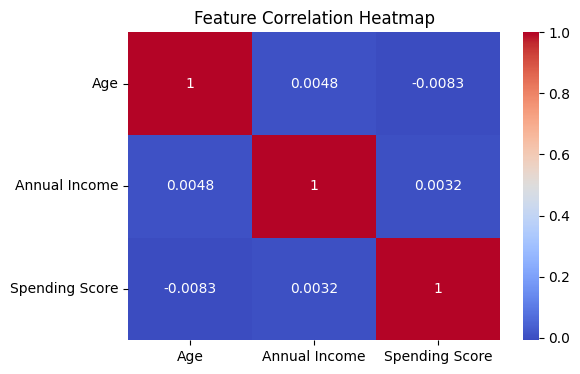

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()
# correlation heatmap visualization


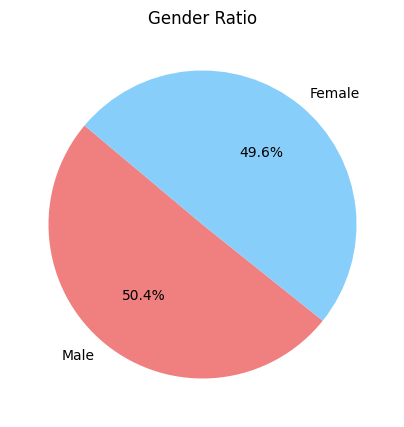

In [19]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'lightskyblue'])
plt.title('Gender Ratio')
plt.show()
# pie chart for Spending Score
# pie chart visualization

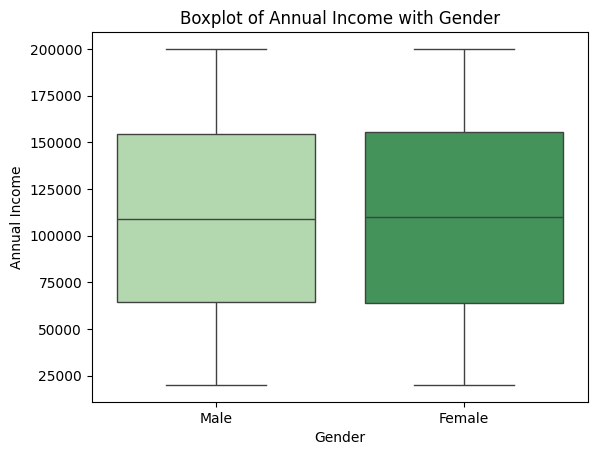

In [20]:
sns.boxplot(x = 'Gender', y = "Annual Income", data = df, palette = 'Greens')
plt.title("Boxplot of Annual Income with Gender")
plt.show()

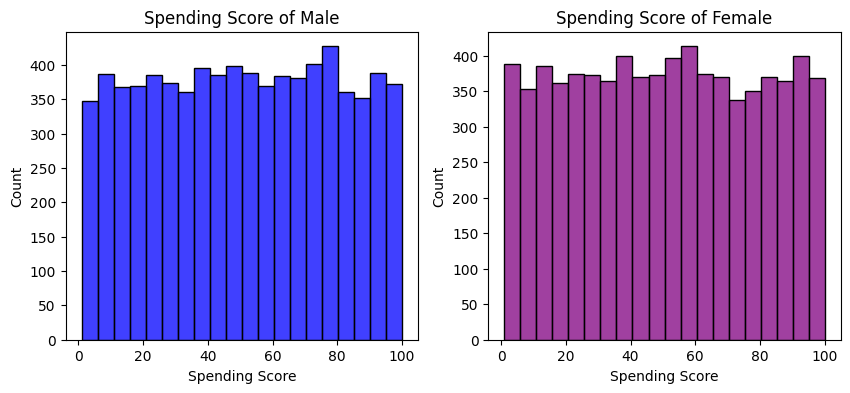

In [21]:

score_male = df[df.Gender == "Male"]["Spending Score"]
score_female = df[df.Gender != "Male"]["Spending Score"]

plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
sns.histplot(score_male, color = "blue")
plt.title("Spending Score of Male")

plt.subplot(1,2,2)
sns.histplot(score_female, color = 'purple')
plt.title("Spending Score of Female")
plt.show()

Text(0.5, 1.0, 'Number of Males and Females')

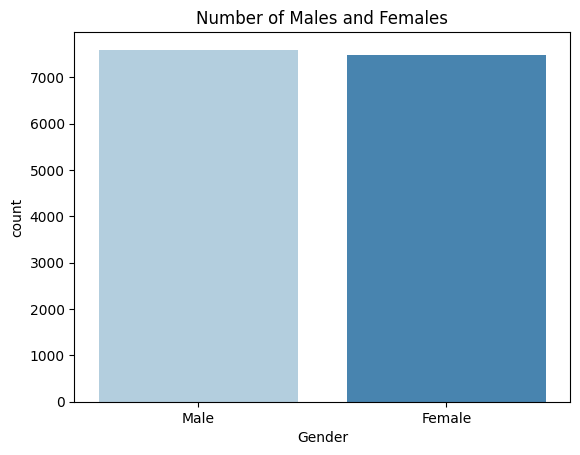

In [22]:
sns.countplot(x = 'Gender', data = df, hue = 'Gender', palette = 'Blues')
plt.title("Number of Males and Females")

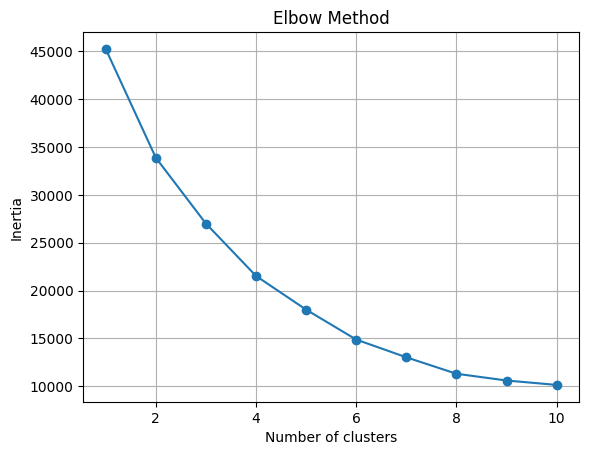

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame as defined in the previous code.
x = df[['Age', 'Annual Income', 'Spending Score']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Find optimal number of clusters (Elbow Method)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

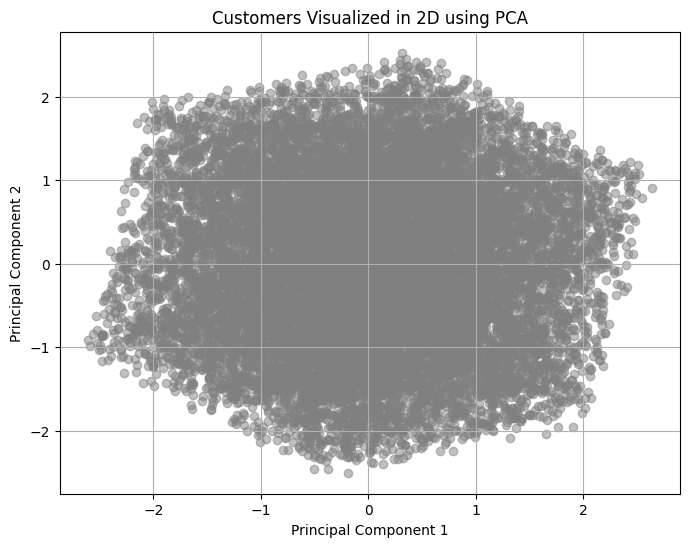

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
from scipy.cluster.hierarchy import dendrogram, linkage


# Assuming X_scaled already exists
# Step 1: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

# Step 2: Visualize the PCA-transformed data
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='gray', alpha=0.5)
plt.title("Customers Visualized in 2D using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()




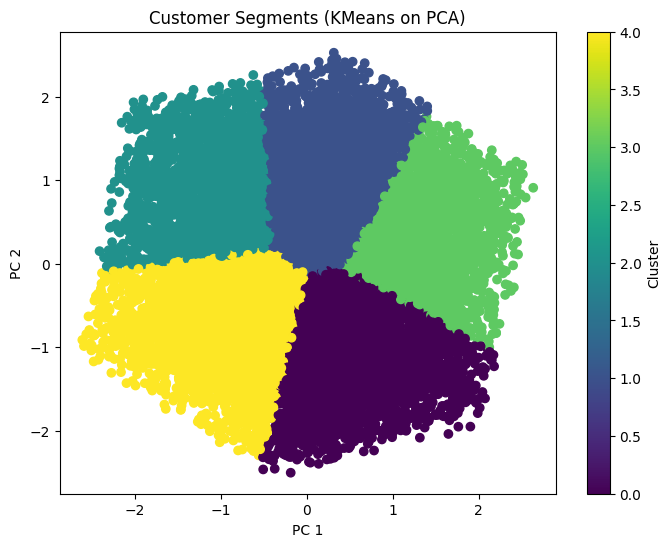

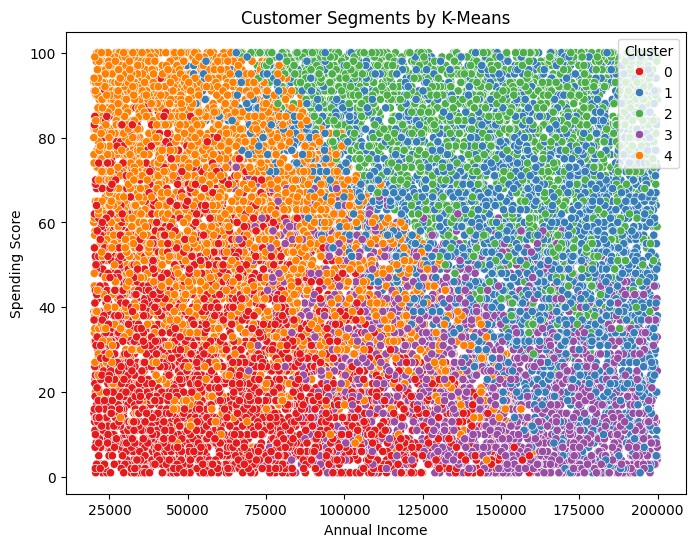

In [26]:

# Step 3: Apply KMeans on PCA data
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Step 4: Add clusters to DataFrame
df['Cluster'] = clusters

# Optional: Visualize clusters in PCA space
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title("Customer Segments (KMeans on PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(label="Cluster")
plt.show()

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income', y='Spending Score',
                hue='Cluster', palette='Set1', data=df)
plt.title("Customer Segments by K-Means")
plt.show()

In [ ]:
# ---------------------- HIERARCHICAL CLUSTERING ----------------------

print("🔍 Trying Agglomerative Clustering with various cluster counts...")

sil_scores = {}
for n_clusters in range(2, 11):
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglom.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    sil_scores[n_clusters] = score

# Find best number of clusters
best_n = max(sil_scores, key=sil_scores.get)
print(f"✅ Best Agglomerative Clustering clusters: {best_n}")
print(f"✅ Best Silhouette Score: {sil_scores[best_n]:.4f}")

# Final Agglomerative Model
agglo = AgglomerativeClustering(n_clusters=best_n)
agglo_labels = agglo.fit_predict(x_scaled)


In [ ]:

# --------------------- DENDROGRAM ---------------------

linked = linkage(x_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=12)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:

# --------------------- CLUSTER VISUALIZATION ---------------------

# Add cluster labels to original dataframe
df['KMeans_Cluster'] = kmeans_labels
df['Agglo_Cluster'] = agglo_labels

# KMeans cluster plot
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', palette='tab10')
plt.title("KMeans Customer Segments")
plt.show()

# Agglomerative cluster plot
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agglo_Cluster', palette='Set2')
plt.title("Hierarchical (Agglomerative) Customer Segments")
plt.show()
